# Todo

1. Just start everything with the adata_ref and vis, and remove the copy that is in the "MT removal" section

# Packages

In [1]:
import cell2location

In [2]:
import pandas as pd
import numpy as np 
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


from matplotlib import rcParams

rcParams['pdf.fonttype'] = 42 # enables correct plotting of text for PDFs

In [3]:
from pathlib import Path
from scipy import sparse # Dealing with adata data dyptes numbers

In [4]:

import torch
torch.set_float32_matmul_precision("high")  # or "medium"
# to deal with this warning
# You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. 
# To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` 
# which will trade-off precision for performance. For more details, read 
# https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision

## SC: GPU

In [5]:
# SC for GPU
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Current device:", torch.cuda.current_device())
    print("Device name:", torch.cuda.get_device_name(0))


Torch version: 2.5.1
CUDA available: True
CUDA version (torch): 12.4
GPU count: 1
Current device: 0
Device name: NVIDIA A100-PCIE-40GB


In [6]:
import torch, scvi
print(torch.__version__, torch.cuda.is_available(), torch.cuda.get_device_name(0))

2.5.1 True NVIDIA A100-PCIE-40GB


# Data

## Locations

In [15]:
proj_folder   = Path("/home/janzules/spatial/CAR-T/data/cell2location")
input_folder  = proj_folder / "cell2location_inputs"

# ref_loc       = input_folder / "ref_adata_c2l_model.h5ad"  saved adata_file with the training at:
spatial_loc   = input_folder / "spatial_sdata_c2l_model.h5ad"

# Output location
ref_run_name   = proj_folder / "reference_signatures"
run_name       = proj_folder / "cell2location_map"

# After training
adata_ref_file     = ref_run_name / "sc_with_signatures.h5ad"

## Data Prep - sdata

In [16]:
# Loading Data

sdata_c2l_model = sc.read_h5ad(spatial_loc)
# adata_ref_c2l_model = sc.read_h5ad(ref_loc) # Already created a 


In [10]:
# Changing the datatype

# spatial
sdata_c2l_model.X = sdata_c2l_model.X.tocsr()
sdata_c2l_model.X.data = sdata_c2l_model.X.data.astype(np.float32)

# reference
adata_ref_c2l_model.X = adata_ref_c2l_model.X.tocsr()
adata_ref_c2l_model.X.data = adata_ref_c2l_model.X.data.astype(np.float32)


In [11]:

# Creating the column that will match the sc reference
sdata_c2l_model.obs['treatment'] = sdata_c2l_model.obs['condition'].astype(str)

# Convert tumor_loc robustly: category -> string -> numeric
sdata_c2l_model.obs['tumor_loc'] = pd.to_numeric(
    sdata_c2l_model.obs['tumor_loc'].astype(str).str.strip(),
    errors='coerce'
).astype('Int64')  # nullable integer dtype

tumor_locations = [1, 2]

for tumor in tumor_locations:
    suffix = f"_Tu{tumor}"
    tum_loc_mask = sdata_c2l_model.obs["tumor_loc"].eq(tumor)

    sdata_c2l_model.obs.loc[tum_loc_mask, 'treatment'] = (
        sdata_c2l_model.obs.loc[tum_loc_mask, 'treatment']
        .str.replace(r"T72", "TAG72", regex=True)
        + suffix
    )


In [12]:
# Creating batch_core label that contains TMA+Mouse Tissue label together.
sdata_c2l_model.obs["batch_core"] = (
    sdata_c2l_model.obs["TMA"].astype(str) + "__" +
    sdata_c2l_model.obs["tissue"].astype(str)
).astype("category")

### MT removal

In [ ]:
# # This is getting moved to the DataPrepForC2L notebook, but leaving here for now

# adata_vis = sdata_c2l_model.copy()
# adata_ref = adata_ref_c2l_model.copy()

# # Quick checks
# print(adata_vis.shape, adata_ref.shape)
# print("vis var_names example:", adata_vis.var_names[:3].tolist())
# print("ref var_names example:", adata_ref.var_names[:3].tolist())
# print("vis SYMBOL example:", adata_vis.var["SYMBOL"].head().tolist() if "SYMBOL" in adata_vis.var else "NO SYMBOL")
# print("ref SYMBOL example:", adata_ref.var["SYMBOL"].head().tolist() if "SYMBOL" in adata_ref.var else "NO SYMBOL")

# # Optional but recommended: remove mitochondrial genes for mapping (based on SYMBOL, not var_names)
# if "SYMBOL" not in adata_vis.var.columns:
#     raise ValueError("adata_vis.var['SYMBOL'] not found. Needed to filter mitochondrial genes with Ensembl var_names.")

# sym_vis = adata_vis.var["SYMBOL"].astype(str).fillna("")
# mt_mask = sym_vis.str.startswith(("mt-", "MT-")).to_numpy()

# # Save which MT genes you're about to remove (must be done BEFORE filtering)
# removed_mt = adata_vis.var.loc[mt_mask, ["SYMBOL"]].copy()
# removed_mt["ensembl"] = adata_vis.var_names[mt_mask].to_numpy()

# # QC metric: MT counts per segmented cell
# adata_vis.obs["mt_counts"] = np.asarray(adata_vis[:, mt_mask].X.sum(axis=1)).ravel() if mt_mask.any() else 0

# # Now remove MT genes
# adata_vis = adata_vis[:, ~mt_mask].copy()
# print("After MT removal:", adata_vis.shape)
# print("MT genes removed:", int(mt_mask.sum()))


(427296, 16784) (135379, 16784)
vis var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']
ref var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']
vis SYMBOL example: ['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1']
ref SYMBOL example: ['Xkr4', 'Rp1', 'Sox17', 'Lypla1', 'Tcea1']
After MT removal: (427296, 16771)
MT genes removed: 13


#### SC - Naming

In [14]:
sdata_c2l_model.obs['batch_core'].unique()

['F07839__CyPSCA_1_1', 'F07840__CyPSCA_1_2', 'F08542__CyPSCA_2_4', 'F07840__CyT72_1_4', 'F08542__CyT72_2_3', ..., 'F07840__RTCyT72_2_4', 'F08543__CyT72_1_2', 'F08543__NoTx_2_4', 'F08543__RTCyPSCA_2_3', 'F08543__RTCyT72_1_1']
Length: 16
Categories (16, object): ['F07839__CyPSCA_1_1', 'F07839__NoTx_2_2', 'F07839__RTCyPSCA_1_4', 'F07839__RTCyT72_2_1', ..., 'F08543__CyT72_1_2', 'F08543__NoTx_2_4', 'F08543__RTCyPSCA_2_3', 'F08543__RTCyT72_1_1']

In [55]:
len(adata_ref.obs['Library'].unique())

30

In [15]:
sdata_c2l_model.obs

,sample,cell_id,region,TMA,mouse,tissue,condition,tumor_loc,replicate_num,treatment,batch_core
F07839_cellid_000000001-1,F07839,F07839_cellid_000000001-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000002-1,F07839,F07839_cellid_000000002-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000004-1,F07839,F07839_cellid_000000004-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000005-1,F07839,F07839_cellid_000000005-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000006-1,F07839,F07839_cellid_000000006-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
...,...,...,...,...,...,...,...,...,...,...,...
F08543_cellid_000070488-1,F08543,F08543_cellid_000070488-1,RTCyT72_1_1_cell_boundaries,F08543,RTCyT72_1_1,RTCyT72_1_1,RTCyT72,1,1,RTCyTAG72_Tu1,F08543__RTCyT72_1_1
F08543_cellid_000070489-1,F08543,F08543_cellid_000070489-1,RTCyT72_1_1_cell_boundaries,F08543,RTCyT72_1_1,RTCyT72_1_1,RTCyT72,1,1,RTCyTAG72_Tu1,F08543__RTCyT72_1_1
F08543_cellid_000070490-1,F08543,F08543_cellid_000070490-1,RTCyT72_1_1_cell_boundaries,F08543,RTCyT72_1_1,RTCyT72_1_1,RTCyT72,1,1,RTCyTAG72_Tu1,F08543__RTCyT72_1_1
F08543_cellid_000070491-1,F08543,F08543_cellid_000070491-1,RTCyT72_1_1_cell_boundaries,F08543,RTCyT72_1_1,RTCyT72_1_1,RTCyT72,1,1,RTCyTAG72_Tu1,F08543__RTCyT72_1_1


# Training Ref (DONE)

## Selecting important genes

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


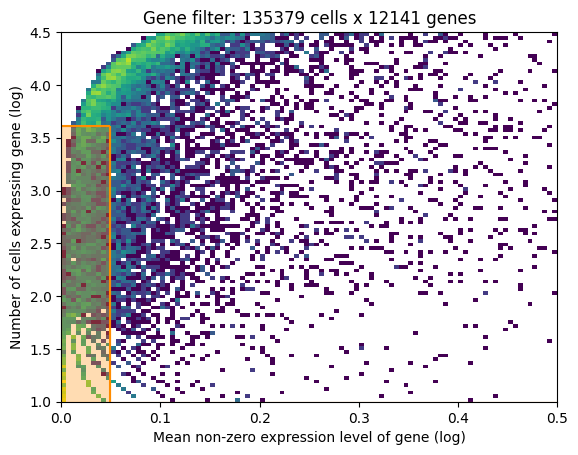

In [57]:
from cell2location.utils.filtering import filter_genes
selected = filter_genes(adata_ref, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

In [58]:
# filter the object
adata_ref = adata_ref[:, selected].copy()

In [60]:
adata_ref.obs['sctype_classification'].unique()

['Neutrophils', 'Macrophage', 'Fibroblast', 'T_cell', 'Monocyte', ..., 'NK_cell', 'Endothelial', 'CAR_T_cell', 'Erythrocyte', 'B/T_cell']
Length: 12
Categories (12, object): ['B/T_cell', 'B_cell', 'CAR_T_cell', 'DC', ..., 'Monocyte', 'NK_cell', 'Neutrophils', 'T_cell']

## Training

In [65]:
# prepare anndata for the regression model
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        batch_key='Library',
                        # cell type, covariate used for constructing signatures
                        labels_key='sctype_classification'
                       )

In [66]:
# create the regression model
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)

# view anndata_setup as a sanity check
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.4.1.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'Library',
│   'labels_key': 'sctype_classification',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   30   │
│         n_cells          │ 135379 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   12   │
│          n_vars          │ 12141  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                    
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location    ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['Library'] │   56948    │          0          │
│                      │   56949    │          1          │
│                      │   56950    │          2          │
│                      │   56951    │          3          │
│                      │   56952    │          4          │
│                      │   56953    │          5          │
│                      │   56954    │          6          │
│                      │   56955    │          7          │
│                      │   56956    │          8          │
│                      │   56957    │          9          │
│                      │   56958    │         10          │
│                      │   56959    │         11          │
│                      │   56960    │         12          │
│                      │   56961    │         13          │
│                      │   56962    │         14          │
│                      │   56963    │         15          │
│                      │   56964    │         16          │
│                      │   56965    │         17          │
│                      │   56966    │         18          │
│                      │   56967    │         19          │
│                      │   56968    │         20          │
│                      │   56969    │         21          │
│                      │   56970    │         22          │
│                      │   56971    │         23          │
│                      │   56972    │         24          │
│                      │   56973    │         25          │
│                      │   56974    │         26          │
│                      │   56975    │         27          │
│                      │   56976    │         28          │
│                      │   56977    │         29          │
└──────────────────────┴────────────┴─────────────────────┘

                          labels State Registry                           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃          Source Location           ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sctype_classification'] │  B/T_cell   │          0          │
│                                    │   B_cell    │          1          │
│                                    │ CAR_T_cell  │          2          │
│                                    │     DC      │          3          │
│                                    │ Endothelial │          4          │
│                                    │ Erythrocyte │          5          │
│                                    │ Fibroblast  │          6          │
│                                    │ Macrophage  │          7          │
│                                    │  Monocyte   │          8          │
│                                    │   NK_cell   │          9          │
│                                    │ Neutrophils │         10          │
│                                    │   T_cell    │         11          │
└────────────────────────────────────┴─────────────┴─────────────────────┘

In [68]:
mod.train(max_epochs=250)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/pytorch/trainer/configuration_validator.py:68: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
You are using a CUDA device ('NVIDIA A100-PCIE-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_m

Training:   0%|          | 0/250 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=250` reached.


### Saving

In [70]:
# In this section, we export the estimated cell abundance (summary of the posterior distribution).
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

Sampling local variables, batch:   0%|          | 0/55 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/999 [00:00<?, ?it/s]

In [71]:
# Save model
mod.save(f"{ref_run_name}", overwrite=True) # ref_run_name created at location

# Save anndata object with results
adata_file = f"{ref_run_name}/sc.h5ad"
adata_ref.write(adata_file)
adata_file

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


'/home/janzules/spatial/CAR-T/data/cell2location/reference_signatures/sc.h5ad'

In [78]:
adata_ref = mod.export_posterior(
    adata_ref,
    add_to_varm=["means", "stds", "q05", "q95"],
    sample_kwargs={"batch_size": 2500, "num_samples": 200},
)


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/janzules/mamba_envs/spatial_gpu_py311/lib/pyth ...


Sampling local variables, batch:   0%|          | 0/55 [00:00<?, ?it/s]

Sampling global variables, sample:   0%|          | 0/199 [00:00<?, ?it/s]

In [81]:
# Should exist after export_posterior:
print("factor_names:", len(adata_ref.uns["mod"]["factor_names"]))
print("varm keys:", list(adata_ref.varm.keys())[:10])
print("has means_per_cluster_mu_fg:", "means_per_cluster_mu_fg" in adata_ref.varm)


factor_names: 12
varm keys: ['means_per_cluster_mu_fg', 'stds_per_cluster_mu_fg', 'q05_per_cluster_mu_fg', 'q95_per_cluster_mu_fg', 'q50_per_cluster_mu_fg', 'q0001_per_cluster_mu_fg']
has means_per_cluster_mu_fg: True


In [82]:
adata_ref.write(f"{ref_run_name}/sc_with_signatures.h5ad")

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/anndata/_io/utils.py:243: FutureWarning: Forward slashes will be disallowed in h5 stores in the next minor release
  return func(*args, **kwargs)


### QC

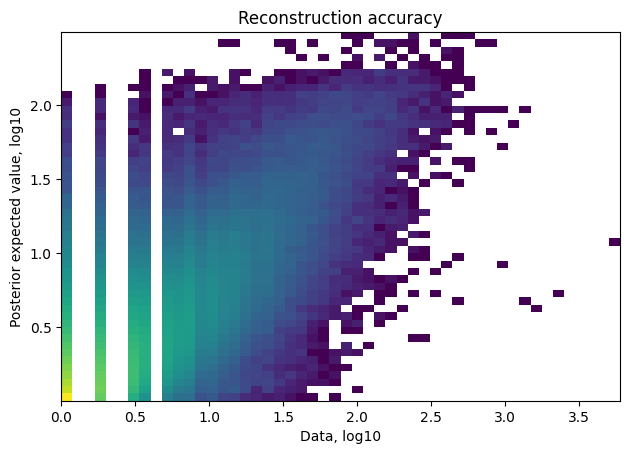

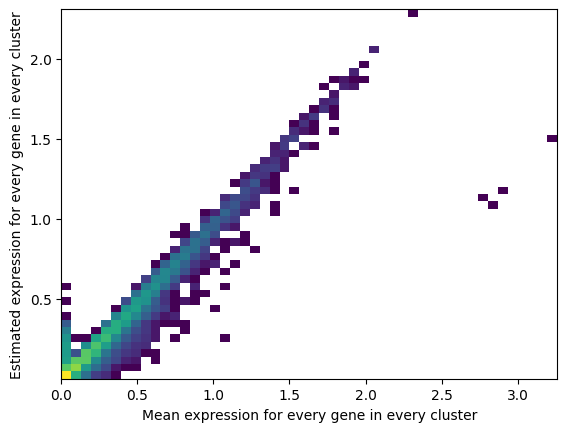

In [79]:
mod.plot_QC()

In [80]:
adata_ref.obs["sctype_classification"].value_counts()


sctype_classification
Monocyte       61613
Macrophage     31399
Fibroblast     18788
DC              6874
B_cell          5778
Neutrophils     3885
T_cell          3031
NK_cell         2362
Endothelial      800
CAR_T_cell       591
B/T_cell         152
Erythrocyte      106
Name: count, dtype: int64

## Reloading ref training

# Training spatial

## Reloading sc training

In [ ]:
# Loading saved data
adata_ref       = sc.read_h5ad(adata_ref_file) 
# mod = cell2location.models.RegressionModel.load(f"{ref_run_name}", adata_ref)

In [ ]:
adata_ref.varm

AxisArrays with keys: means_per_cluster_mu_fg, q0001_per_cluster_mu_fg, q05_per_cluster_mu_fg, q50_per_cluster_mu_fg, q95_per_cluster_mu_fg, stds_per_cluster_mu_fg

In [ ]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,B/T_cell,B_cell,CAR_T_cell,DC,Endothelial
gene_id,,,,,
ENSMUSG00000051951,0.031992,0.001949,0.002054,0.003468,0.008911
ENSMUSG00000025900,0.019777,0.000429,0.003582,0.000244,0.010231
ENSMUSG00000025902,0.007540,0.000168,0.001827,0.000199,0.637525
ENSMUSG00000025903,0.329970,0.111627,0.032036,0.310520,0.201191
ENSMUSG00000033813,0.959093,0.412800,0.074074,0.758402,0.274767


## Mapping

In [ ]:
# find shared genes and subset both anndata and reference signatures
intersect = np.intersect1d(adata_vis.var_names, inf_aver.index)
adata_vis = adata_vis[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata=adata_vis, batch_key="sample")

# Testing

In [47]:
adata_ref.shape

(135379, 16784)

In [27]:
adata_vis.obs.shape

(427296, 11)

In [ ]:
# Remov
adata_vis = sdata_c2l_model.copy()
adata_ref = adata_ref_c2l_model.copy()

In [39]:
adata_vis

AnnData object with n_obs × n_vars = 427296 × 16784
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'treatment', 'batch_core'
    var: 'SYMBOL'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [28]:
# Quick checks
print(adata_vis.obs.shape, adata_ref.obs.shape)
print("vis var_names example:", adata_vis.var_names[:3].tolist())
print("ref var_names example:", adata_ref.var_names[:3].tolist())

(427296, 11) (135379, 17)
vis var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']
ref var_names example: ['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902']


In [32]:
sym = adata_vis.var_names.astype(str)
sym

Index(['ENSMUSG00000051951', 'ENSMUSG00000025900', 'ENSMUSG00000025902',
       'ENSMUSG00000025903', 'ENSMUSG00000033813', 'ENSMUSG00000002459',
       'ENSMUSG00000033793', 'ENSMUSG00000025905', 'ENSMUSG00000025907',
       'ENSMUSG00000087247',
       ...
       'ENSMUSG00000064354', 'ENSMUSG00000064356', 'ENSMUSG00000064357',
       'ENSMUSG00000064358', 'ENSMUSG00000064360', 'ENSMUSG00000065947',
       'ENSMUSG00000064363', 'ENSMUSG00000064367', 'ENSMUSG00000064368',
       'ENSMUSG00000064370'],
      dtype='object', name='gene_id', length=16784)

In [37]:
adata_vis.var['SYMBOL']
adata_ref.var['SYMBOL']

gene_id
ENSMUSG00000051951       Xkr4
ENSMUSG00000025900        Rp1
ENSMUSG00000025902      Sox17
ENSMUSG00000025903     Lypla1
ENSMUSG00000033813      Tcea1
                       ...   
ENSMUSG00000065947    mt-Nd4l
ENSMUSG00000064363     mt-Nd4
ENSMUSG00000064367     mt-Nd5
ENSMUSG00000064368     mt-Nd6
ENSMUSG00000064370    mt-Cytb
Name: SYMBOL, Length: 16784, dtype: object

In [29]:
# Optional but recommended: remove mitochondrial genes for mapping (keep counts separately if you want)
# Mouse MT genes often start with "mt-" or "MT-"
sym = adata_vis.var_names.astype(str)
mt_mask = np.array([g.startswith("mt-") or g.startswith("MT-") for g in sym])

adata_vis.obsm["MT"] = adata_vis[:, mt_mask].X.toarray() if mt_mask.any() else None
adata_vis = adata_vis[:, ~mt_mask].copy()

print("After MT removal:", adata_vis.shape)

AttributeError: 'NoneType' object has no attribute 'shape'

## T: Exploring batch options

In [38]:
sdata_c2l_model.obs["batch_core"].value_counts().describe()

count       16.000000
mean     26706.000000
std      16387.594605
min       2747.000000
25%      16844.000000
50%      24401.500000
75%      33277.000000
max      65864.000000
Name: count, dtype: float64

In [37]:
cands = ["TMA", "sample", "tissue", "region", "mouse", "condition", "tumor_loc", "treatment", "batch_core"]
for k in cands:
    if k in sdata_c2l_model.obs.columns:
        vc = sdata_c2l_model.obs[k].value_counts()
        print(f"\n{k}: n={vc.size}, median={vc.median():.0f}, min={vc.min()}, max={vc.max()}")


TMA: n=4, median=94946, min=58530, max=178874

sample: n=4, median=94946, min=58530, max=178874

tissue: n=16, median=24402, min=2747, max=65864

region: n=16, median=24402, min=2747, max=65864

mouse: n=16, median=24402, min=2747, max=65864

condition: n=5, median=88824, min=49249, max=112113

tumor_loc: n=2, median=213648, min=162879, max=264417

treatment: n=10, median=38413, min=2747, max=97293

batch_core: n=16, median=24402, min=2747, max=65864


In [18]:
sdata_c2l_model.obs.head()

,sample,cell_id,region,TMA,mouse,tissue,condition,tumor_loc,replicate_num,treatment,batch_core
F07839_cellid_000000001-1,F07839,F07839_cellid_000000001-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000002-1,F07839,F07839_cellid_000000002-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000004-1,F07839,F07839_cellid_000000004-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000005-1,F07839,F07839_cellid_000000005-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1
F07839_cellid_000000006-1,F07839,F07839_cellid_000000006-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,F07839__CyPSCA_1_1


In [19]:
adata_ref_c2l_model.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,Barcode,Library,condition,file_name,percent.mt,unintegrated_clusters,seurat_clusters,harmony_clusters,sctype_classification,seurat.cluster.ann,treatment,cell_type,UMAP_R_1,UMAP_R_2
56948_AAACGAACACTAGGTT-1,NoTx,2142,851,AAACGAACACTAGGTT-1,56948,NoTx,NoTx_Tu1_1,9.290383,10,9,9,Neutrophils,9: Neutrophils,NoTx_Tu1,Neutrophils,5.049781,-9.935757
56948_AAACGCTGTTGGGTTT-1,NoTx,1897,658,AAACGCTGTTGGGTTT-1,56948,NoTx,NoTx_Tu1_1,5.640485,10,9,9,Neutrophils,9: Neutrophils,NoTx_Tu1,Neutrophils,6.671258,-9.771027
56948_AAACGCTTCCTCGATC-1,NoTx,16414,3769,AAACGCTTCCTCGATC-1,56948,NoTx,NoTx_Tu1_1,4.563178,6,3,3,Macrophage,3: Macrophage,NoTx_Tu1,Macrophage,7.841278,3.778570
56948_AAAGAACCAATACAGA-1,NoTx,8973,2987,AAAGAACCAATACAGA-1,56948,NoTx,NoTx_Tu1_1,2.084030,6,3,3,Macrophage,3: Macrophage,NoTx_Tu1,Macrophage,8.648595,2.988089
56948_AAAGAACCACAGGATG-1,NoTx,693,452,AAAGAACCACAGGATG-1,56948,NoTx,NoTx_Tu1_1,16.161616,3,2,2,Fibroblast,2: Fibroblast,NoTx_Tu1,Fibroblast,-4.163362,-6.711728


In [20]:
sdata_c2l_model.var

,SYMBOL
gene_id,
ENSMUSG00000051951,Xkr4
ENSMUSG00000025900,Rp1
ENSMUSG00000025902,Sox17
ENSMUSG00000025903,Lypla1
ENSMUSG00000033813,Tcea1
...,...
ENSMUSG00000065947,mt-Nd4l
ENSMUSG00000064363,mt-Nd4
ENSMUSG00000064367,mt-Nd5


In [21]:
adata_ref_c2l_model.var

,SYMBOL
gene_id,
ENSMUSG00000051951,Xkr4
ENSMUSG00000025900,Rp1
ENSMUSG00000025902,Sox17
ENSMUSG00000025903,Lypla1
ENSMUSG00000033813,Tcea1
...,...
ENSMUSG00000065947,mt-Nd4l
ENSMUSG00000064363,mt-Nd4
ENSMUSG00000064367,mt-Nd5
